# 03: LIDC-IDRI Dataset Visualisation

This notebook explores the real CT data we train and evaluate on, with the aim of understanding:

- What the LIDC-IDRI dataset is and where it comes from
- The raw to processed preprocessing pipeline applied by LION
- What real CT slices look like
- The intensity distribution and normalisation convention
- How LION's dataloader serves images to the training loop
- The train/validation/test split used in our experiments

This exploration is directly relevant to the project as it helps understand how data is normalised, as well as what format it needs to be in at each point of the model pipeline.

### Note

This notebook does all of its explorations on `data/subset_10/`, which is a 10-patient subset for local development. The full dataset (~125 GB, ~1000 patients) lives on CSD3 and is used in later stages of the project.

## 1. Setup

In [1]:
# import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.transform import radon, iradon
from pathlib import Path
import os

# add error handling for pydicom import
try:
    import pydicom
    HAS_DICOM = True
except ImportError:
    HAS_DICOM = False
    print("pydicom not installed — raw DICOM cells will be skipped.")

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# create output directory for figures
output_dir = Path("../figures/03")
output_dir.mkdir(parents=True, exist_ok=True)

# set up and print paths to raw and processed data directories
NOTEBOOK_DIR  = Path.cwd()
DATA_ROOT     = NOTEBOOK_DIR.parent / "data" / "subset_10"
RAW_DIR       = DATA_ROOT / "raw" / "LIDC-IDRI" / "LIDC-IDRI"
PROCESSED_DIR = DATA_ROOT / "processed" / "LIDC-IDRI"

print(f"Data root      : {DATA_ROOT}")
print(f"Raw DICOM dir  : {RAW_DIR}")
print(f"Processed dir  : {PROCESSED_DIR}")

Data root      : /rds/user/eaz21/hpc-work/ct_reconstruction/data/subset_10
Raw DICOM dir  : /rds/user/eaz21/hpc-work/ct_reconstruction/data/subset_10/raw/LIDC-IDRI/LIDC-IDRI
Processed dir  : /rds/user/eaz21/hpc-work/ct_reconstruction/data/subset_10/processed/LIDC-IDRI


### A note on displaying CT images

Before visualising any images it is important to understand how the data is stored.

The processed `.npy` files contain raw int16 Hounsfield Unit (HU) values, not pre-normalised pixel values. 

The full physical range of HU values in a CT scan has a very large span, and passing this directly to `imshow` with `vmin=0, vmax=1` clamps everything
to white as almost all HU values are orders of magnitude larger than 1. To display images correctly, I applied a lung window to clip all images to [−1000, +400] HU, which is the clinically relevant range for a chest CT. The image is then rescaled to [0, 1] for consistency.

This window is applied as a function and used is every visualisation throughout this notebook for visual purposes. The data in the project is normalised from HU to physically meaningful linear attenuation coefficients, but that is used for computational purposes only.

In [2]:
def apply_lung_window(arr, hu_min=-1000, hu_max=400):

    """Clip to HU range and normalise to [0, 1] for display only."""

    # clip to HU range
    clipped = np.clip(arr.astype(np.float32), hu_min, hu_max)

    # normalise to [0, 1]
    return (clipped - hu_min) / (hu_max - hu_min)

## 2. About the LIDC-IDRI Dataset

The **Lung Image Database Consortium and Image Database Resource Initiative (LIDC-IDRI)** is the standard benchmark dataset for CT reconstruction research, and is the dataset of choice for this project due to its already strong integration with LION.

Key facts:
- Contains chest CT scans of 1,018 patients
- Collected from 7 academic medical centres
- Publicly available via the Cancer Imaging Archive (TCIA)
- Used in LION's default dataloader

#### Why chest CT? 

Lung CT has high contrast between soft tissue, air-filled lungs, and bone, which makes it a challenging and representative benchmark for reconstruction algorithms.

#### `subset_10` 

For the purposes of trainig on local data first, the subset is copied over from the full dataset and contains 10 patients (LIDC-IDRI-0001 through 0010), which is sufficient for development and debugging before proceeding with the full training on CSD3.

## 3. Dataset Directory Structure

It is helpful to understand the structure of the dataset before working with any of the images. This is because the processed directory contains two distinct types of `.npy` file, `slice_*.npy` (CT images) and `mask_*.npy` (nodule annotation masks), which must be handled separately. Accidentally including mask files when loading images will produce incorrect statistics and blank visualisations, so thoroughly exploring the layout in advance helps prevent this from happening.

The raw directory contains the original DICOM files organised by patient and scan session. The processed directory contains the output of LION's preprocessing script (`pre_process_lidc_idri.py`), with one subdirectory per patient.

In [3]:
# visualise directory structure
def print_tree(path, max_depth=3, max_files=3, _prefix="", _depth=0):

    # add error handling for non-existent paths and max depth
    if _depth > max_depth or not Path(path).exists():
        return
    
    # list and sort items, then separate into dirs and files
    items  = sorted(Path(path).iterdir())
    dirs   = [p for p in items if p.is_dir()]
    files  = [p for p in items if p.is_file()]

    # print directories first, then files (limited by max_files)
    for d in dirs:
        print(f"{_prefix}📁 {d.name}/")
        print_tree(d, max_depth, max_files, _prefix + "   ", _depth + 1)
    for f in files[:max_files]:
        print(f"{_prefix}📄 {f.name}  ({f.stat().st_size // 1024} KB)")
    if len(files) > max_files:
        print(f"{_prefix}   ... and {len(files) - max_files} more files")

# print directory trees for raw and processed data
print("=== Raw DICOM structure ===")
print_tree(RAW_DIR, max_depth=3, max_files=2)
print()
print("=== Processed structure ===")
print_tree(PROCESSED_DIR, max_depth=3, max_files=3)

=== Raw DICOM structure ===
📁 LIDC-IDRI-0001/
   📁 01-01-2000-30178/
      📁 3000566.000000-03192/
         📄 069.xml  (302 KB)
         📄 1-001.dcm  (514 KB)
            ... and 133 more files
   📁 01-01-2000-35511/
      📁 3000923.000000-62357/
         📄 068.xml  (3 KB)
         📄 1-1.dcm  (7987 KB)
            ... and 2 more files
📁 LIDC-IDRI-0002/
   📁 01-01-2000-26851/
      📁 3000972.000000-22902/
         📄 070.xml  (3 KB)
         📄 1-1.dcm  (6748 KB)
            ... and 1 more files
   📁 01-01-2000-98329/
      📁 3000522.000000-04919/
         📄 071.xml  (324 KB)
         📄 1-001.dcm  (514 KB)
            ... and 261 more files
📁 LIDC-IDRI-0003/
   📁 01-01-2000-59141/
      📁 3000978.000000-59882/
         📄 073.xml  (8 KB)
         📄 1-1.dcm  (7987 KB)
            ... and 5 more files
   📁 01-01-2000-94866/
      📁 3000611.000000-03264/
         📄 072.xml  (398 KB)
         📄 1-001.dcm  (514 KB)
            ... and 140 more files
📁 LIDC-IDRI-0004/
   📁 01-01-2000-88534/
    

## 4. The Raw Data: DICOM Files

The raw data is stored in **DICOM** format (`.dcm`), which is the medical imaging standard.

Each `.dcm` file corresponds to one 2D CT slice, and a patient folder typically contains 100–500 slices stacked along the z-axis.

DICOM files contain:
- The pixel array (raw Hounsfield Units)
- Rich metadata: patient ID, scanner model, slice thickness, pixel spacing, etc.

`pydicom` is used to read them.

In [4]:
# explore DICOM metadata and pixel data

# add error handling for missing pydicom
if not HAS_DICOM:
    print("Skipping — pydicom not installed.")

else:
    # Find first available DICOM file in the raw directory
    dcm_files = sorted(RAW_DIR.glob("**/*.dcm"))

    # print warning if no DICOM files found
    if not dcm_files:
        print(f"No .dcm files found under {RAW_DIR}")

    # print summary
    else:
        print(f"Found {len(dcm_files)} DICOM files across {len(list(RAW_DIR.glob('LIDC-IDRI-*')))} patients")
        
        # Load one example slice
        dcm = pydicom.dcmread(dcm_files[0])
        print(f"\nExample DICOM metadata:")
        print(f"  File             : {dcm_files[0].name}")
        print(f"  Patient ID       : {getattr(dcm, 'PatientID', 'N/A')}")
        print(f"  Modality         : {getattr(dcm, 'Modality', 'N/A')}")
        print(f"  Rows × Cols      : {getattr(dcm, 'Rows', '?')} × {getattr(dcm, 'Columns', '?')}")
        print(f"  Pixel Spacing    : {getattr(dcm, 'PixelSpacing', 'N/A')} mm")
        print(f"  Slice Thickness  : {getattr(dcm, 'SliceThickness', 'N/A')} mm")
        print(f"  Rescale Slope    : {getattr(dcm, 'RescaleSlope', 'N/A')}")
        print(f"  Rescale Intercept: {getattr(dcm, 'RescaleIntercept', 'N/A')}")

Found 1873 DICOM files across 10 patients

Example DICOM metadata:
  File             : 1-001.dcm
  Patient ID       : LIDC-IDRI-0001
  Modality         : CT
  Rows × Cols      : 512 × 512
  Pixel Spacing    : [0.703125, 0.703125] mm
  Slice Thickness  : 2.500000 mm
  Rescale Slope    : 1
  Rescale Intercept: -1024


DICOM files store raw scanner-dependent pixel integers. These can be converted to Hounsfield Units (HU) using the `RescaleSlope` and `RescaleIntercept` values
stored in the DICOM header:

    HU = RescaleSlope × raw_pixel + RescaleIntercept

HU values are scanner-independent and physically meaningful, as different types of tissue always correspond to the same HU values. All downstream processing
in LION works in HU or in the linear attenuation units derived from it (µ, cm⁻¹).

Raw pixel range  : [-1024, 4095]
HU range         : [-2048, 3071] HU
Image shape      : (512, 512)


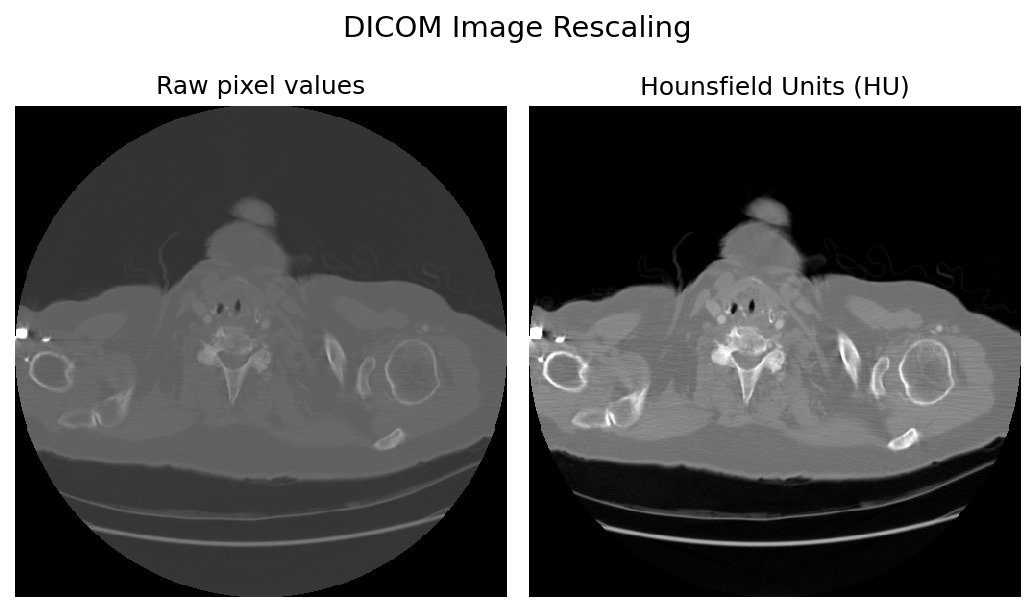

In [5]:
# handle missing pydicom
if not HAS_DICOM:
    print("Skipping — pydicom not installed.")

else:

    # Find first available DICOM file in raw directory
    dcm_files = sorted(RAW_DIR.glob("**/*.dcm"))
    
    if dcm_files:

        # load one example slice and extract raw pixel data
        dcm = pydicom.dcmread(dcm_files[0])
        raw_pixels = dcm.pixel_array.astype(np.float32)

        # calculate slope 
        slope = float(getattr(dcm, 'RescaleSlope', 1.0))

        # calculate intercept
        intercept = float(getattr(dcm, 'RescaleIntercept', 0.0))

        # apply rescaling to HU 
        hu_image  = raw_pixels * slope + intercept
        
        # print summary of ranges and shape
        print(f"Raw pixel range  : [{raw_pixels.min():.0f}, {raw_pixels.max():.0f}]")
        print(f"HU range         : [{hu_image.min():.0f}, {hu_image.max():.0f}] HU")
        print(f"Image shape      : {hu_image.shape}")
        
        # plot raw pixels and HU side by side
        fig, axes = plt.subplots(1, 2, figsize=(7, 4))
        axes[0].imshow(raw_pixels, cmap="gray")
        axes[0].set_title("Raw pixel values")
        axes[0].axis("off")
        
        # set min and max for HU display to typical range for soft tissues
        axes[1].imshow(hu_image, cmap="gray", vmin=-1000, vmax=1000)
        axes[1].set_title("Hounsfield Units (HU)")
        axes[1].axis("off")
        
        plt.suptitle("DICOM Image Rescaling", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.savefig("../figures/03/01_dicom_raw.pdf", bbox_inches="tight")
        plt.show()

The raw pixel image appears relatively low in contrast because the stored pixel values do not directly represent physical tissue attenuation. After conversion to Hounsfield Units (HU), the distinction between different tissue types becomes much clearer, resulting in improved visual contrast throughout the image. Furthermore, HU values have a direct physical interpretation, with different tissues occupying characteristic HU ranges.

## 5. Hounsfield Units (HU): The CT Intensity Scale

CT scanners measure X-ray attenuation, expressed in Hounsfield Units (HU):

| Tissue          | Typical HU range |
|-----------------|-----------------|
| Air             | −1000           |
| Lung (inflated) | −700 to −600    |
| Fat             | −100 to −50     |
| Water           | 0               |
| Soft tissue     | +20 to +80      |
| Bone            | +400 to +1000   |

In clinical settings, Radiologists can adjust the minimum and maximum values of the display window in order to focus on specific tissues.

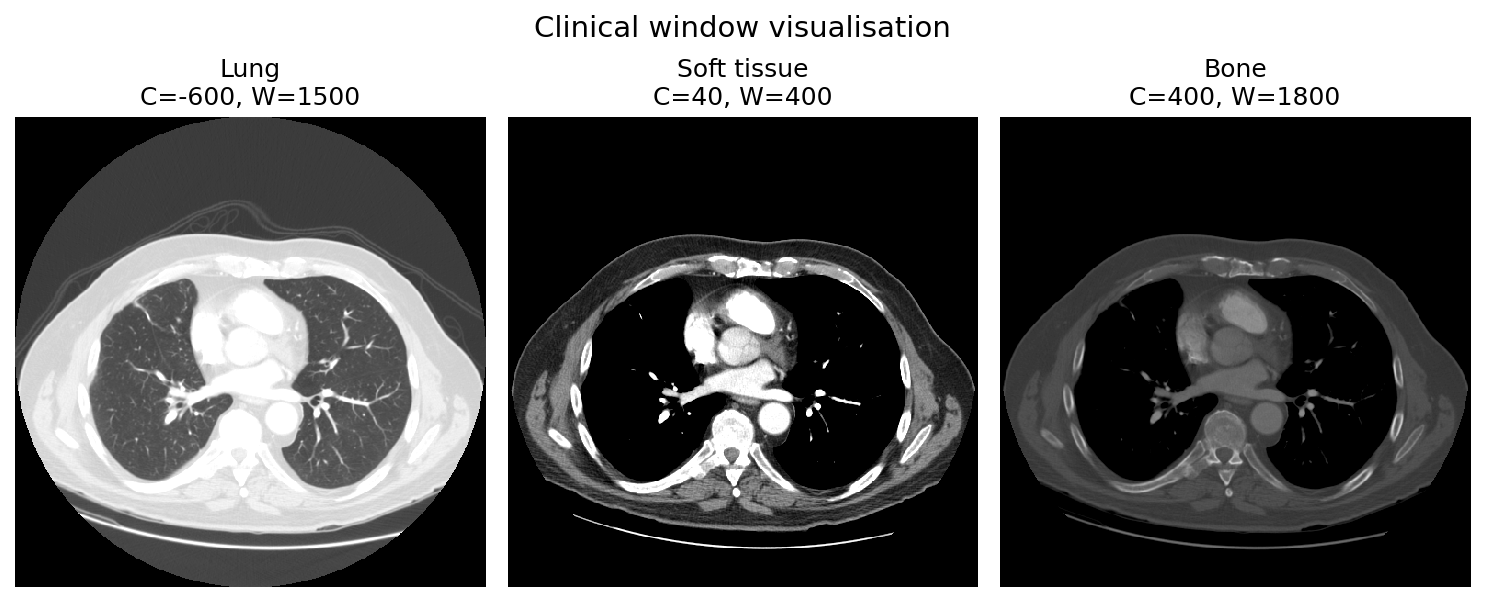

Best slice: 1-083.dcm


In [6]:
# handle missing pydicom
if not HAS_DICOM:
    print("Skipping — pydicom not installed.")

else:

    # Find first available DICOM file in raw directory
    dcm_files = sorted(RAW_DIR.glob("**/*.dcm"))
    if dcm_files:
        
        # select 20 slices from interquartal range of scan
        candidate_slices = dcm_files[len(dcm_files)//4 : len(dcm_files)//4 + 20]
        
        # create variables to track best slice and std
        best_slice = None
        best_std = 0
        best_file = None

        # loop through slices
        for f in candidate_slices:

            # load DICOM
            d = pydicom.dcmread(f)

            # obtain raw pixel values (image)
            p = d.pixel_array.astype(np.float32)
            
            # rescale to HU
            p = p * float(getattr(d, 'RescaleSlope', 1)) + float(getattr(d, 'RescaleIntercept', 0))

            # select slice with highest standard deviation
            if p.std() > best_std:
                best_std = p.std()
                best_slice = p
                best_file = f
        
        # define function to apply windowing for given centre and width
        def apply_window(img_hu, centre, width):
            lo = centre - width / 2
            hi = centre + width / 2
            return np.clip((img_hu - lo) / (hi - lo), 0, 1)
        
        # define common windows for different tissues
        windows = [
            ("Lung",         -600, 1500),
            ("Soft tissue",    40,  400),
            ("Bone",          400, 1800),
        ]
        
        # plot a slice with different window settings
        fig, axes = plt.subplots(1, 3, figsize=(10, 4))

        for ax, (name, ctr, wid) in zip(axes, windows):

            # apply windowing
            windowed = apply_window(best_slice, ctr, wid)

            # display windowed image
            ax.imshow(windowed, cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"{name}\nC={ctr}, W={wid}")
            ax.axis("off")
        
        # show and save figure
        plt.suptitle("Clinical window visualisation", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.savefig("../figures/03/02_hu_windows.pdf", bbox_inches="tight")
        plt.show()

        print(f"Best slice: {Path(best_file).name}")

The effects of different CT window settings can clearly be seen across the figure, despite everything being generated from the same Hounsfield Unit image. The lung window highlights pulmonary parenchyma and airway detail, the soft tissue window improves visualisation of mediastinal and vascular structures, and the bone window enhances high-density anatomy while suppressing soft tissue contrast. This illustrates how clinically meaningful HU values allow image contrast to be tailored to specific diagnostic tasks through windowing, something that would not be possible with raw pixels.

## 6. LION's Preprocessing Pipeline

LION's `pre_process_lidc_idri.py` converts raw DICOM files into `.npy` files using `pylidc` to handle DICOM parsing and annotation extraction.

the `.npy` files store raw `int16` Hounsfield Unit values (range approximately −2048 to +1400) and are not pre-normalised to [0, 1], as this happens inside `LIDC_IDRI.__getitem__()` at load time via `ct.from_HU_to_mu()` (reconstruction) or `ct.from_HU_to_normal()` (segmentation).

The processed directory also contains `mask_*.npy` files which are binary nodule annotation masks, not CT images, and must be excluded when loading slices which is done by using `glob("**/slice_*.npy")`.

File         : LIDC-IDRI-0001/slice_0.npy
dtype        : int16
Value range  : [-2048, 1416] HU
Total slices : 1852 across 10 patients


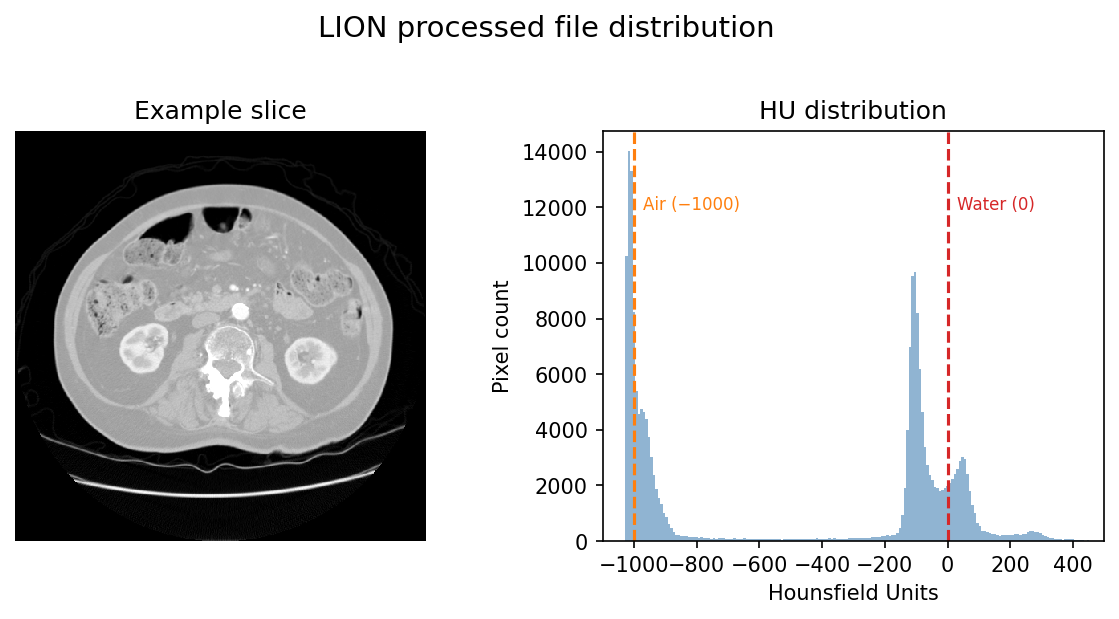

In [7]:
# load processed .npy files and patient count
npy_files = sorted(PROCESSED_DIR.glob("**/slice_*.npy"))
patients  = sorted(set(f.parent.name for f in npy_files))

# add error handling for missing .npy files
if not npy_files:
    print("No slice_*.npy files found. Check your processed data path.")

else:

    # load one example slice to check data type and value range
    raw = np.load(npy_files[0])
    print(f"File         : {npy_files[0].parent.name}/{npy_files[0].name}")
    print(f"dtype        : {raw.dtype}")
    print(f"Value range  : [{raw.min()}, {raw.max()}] HU")

    # print summary of dataset size
    print(f"Total slices : {len(npy_files)} across {len(patients)} patients")

    # plot example slice with lung window and histogram of HU values
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(apply_lung_window(raw), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Example slice")
    axes[0].axis("off")

    pixels = raw.astype(np.float32).ravel()

    # Clip display range to where the data actually lives — removes empty space
    axes[1].hist(pixels, bins=200, color="steelblue", edgecolor="none", alpha=0.6, range=(-1100, 500))

    # Annotate lines directly — offset horizontally to avoid overlap
    axes[1].axvline(-1000, color="C1",    ls="--", lw=1.5)
    axes[1].axvline(    0, color="C3",  ls="--", lw=1.5)

    ymax = axes[1].get_ylim()[1]
    axes[1].text(-970, ymax * 0.8, "Air (−1000)",  color="C1", ha="left", va="bottom", fontsize=8)
    axes[1].text(  30, ymax * 0.8, "Water (0)",    color="C3", ha="left", va="bottom", fontsize=8)

    axes[1].set_xlabel("Hounsfield Units")
    axes[1].set_ylabel("Pixel count")
    axes[1].set_title("HU distribution")
    axes[1].set_xlim(-1100, 500)

    plt.suptitle("LION processed file distribution", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/03_preprocessing_pipeline.pdf", bbox_inches="tight")
    plt.show()

We can see both from the printed output and the histogram that the processed files store Hounsfield Unit values rather than normalised pixel values. The printed
output confirms the `int16` dtype and the value range (approximately −2048 to +1400), and the histogram confirms this further by showing the characteristic bimodal distribution expected from a CT scan, with a sharp peak at −1000 HU corresponding to air (background outside the patient and inside the lungs), and a broader peak centred near −200 to 200 HU corresponding to soft tissue, fat, and organs. If the files had been normalised to [0,1], the same distribution would appear compressed into the [0, 1] range on the x-axis.

This confirms that `ct.from_HU_to_mu()` must be applied at load time before passing images to the CT operator, and this is exactly what LION's `LIDC_IDRI.__getitem__()` does automatically when set to `task="reconstruction"`.

## 7. Slice Gallery: Real Lung CT

The model trains on the processed data, so to understand what it is seeing, we visualise a sample of slices by creating a slice gallery.

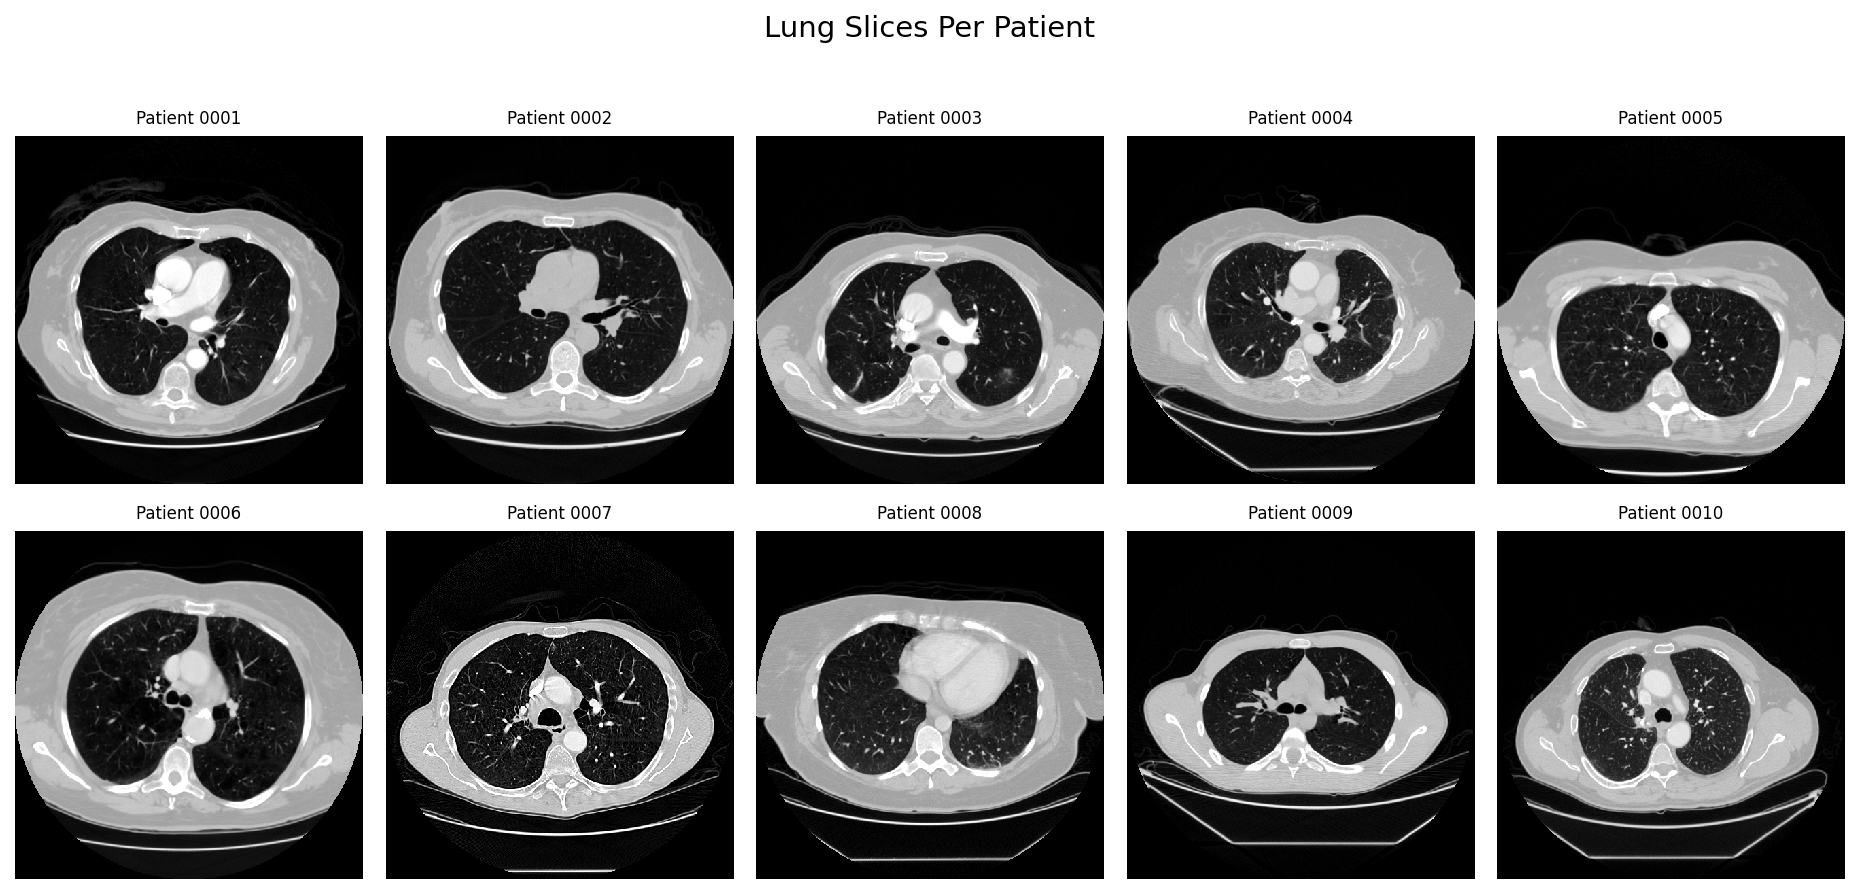

In [8]:
if npy_files:

    def lung_score(fpath, dark_threshold=-500):
        """
        Returns a score indicating likelihood of slice containing lung fields by checking for dark pixels in central 50% of image.
        """
        img = np.load(fpath).astype(np.float32)
        h, w = img.shape

        # define the centre by setting margins to 25% of height and 20% of width
        centre = img[h//4 : 3*h//4, w//5 : 4*w//5]
        return (centre < dark_threshold).mean()

    # Pick best lung slice per patient
    gallery_files = []
    for pat in patients:

        # sort files 
        pat_files = sorted(f for f in npy_files if f.parent.name == pat)

        # manually handle 0009 as the pipeline was failing
        if pat == "LIDC-IDRI-0009":
            gallery_files.append(pat_files[int(len(pat_files) * 0.2)])
            continue

        # score slices by lung likelihood and pick the best one above threshold
        lung_files = [f for f in pat_files if lung_score(f) > 0.15]
        if lung_files:
            gallery_files.append(max(lung_files, key=lung_score))
        else:
            gallery_files.append(max(pat_files, key=lambda f: np.load(f).std()))

    # plot gallery of slices across two rows
    n     = len(gallery_files)
    ncols = min(5, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 3))
    axes = np.array(axes).reshape(-1) if n > 1 else [axes]

    for ax, fpath in zip(axes, gallery_files):
        img = np.load(fpath).astype(np.float32)
        ax.imshow(apply_lung_window(img), cmap="gray", vmin=0, vmax=1)
        ax.set_title(fpath.parent.name.replace("LIDC-IDRI-", "Patient "), fontsize=8)
        ax.axis("off")

    for ax in axes[len(gallery_files):]:
        ax.set_visible(False)

    # show and save figure
    plt.suptitle("Lung Slices Per Patient", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/04_slice_gallery.pdf", bbox_inches="tight")
    plt.show()

The figure above shows one representative lung slice from each patient in the subset dataset. Slices were selected automatically by identifying images containing a sufficiently large proportion of lung-like pixels (HU < -500) within the central region of the scan, ensuring that the chosen slice contained visible pulmonary anatomy rather than the neck or upper abdomen. The only anomaly was patient 0009, whose slice had to be selected manually due to the different ordering of the slices in the patient folder. All images are displayed using a lung window (-1000 to +400 HU), highlighting the lung parenchyma and demonstrating the anatomical diversity present across the cohort.

## 8. Exploring a 3D Volume: Axial, Coronal, Sagittal Views

CT data is inherently 3D. Although LION processes each 2D axial slice independently for reconstruction, understanding the 3D structure of the data helps build intuition for what the model is learning and why certain slices are more informative than others.

A CT volume can be viewed from three orthogonal planes:

- **Axial:** a horizontal cross-section through the body, as if looking down from above. This is the standard clinical CT view and the one used for reconstruction. Each `.npy` file in the processed dataset is one axial slice of the patient.
- **Coronal:** a vertical cross-section from front to back, dividing the body into anterior and posterior halves. It is useful for seeing the full extent of the lungs from top to bottom.
- **Sagittal:** a vertical cross-section from left to right, dividing the body into left and right halves. Shows the spine and chest cavity in profile.

All three views are derived from the same 3D volume, where axial slices are stacked along the depth axis and cross-sections are taken in each direction.

Patient      : LIDC-IDRI-0001
Volume shape : (133, 512, 512)  (depth × height × width)
HU range     : [-2048, 3071]


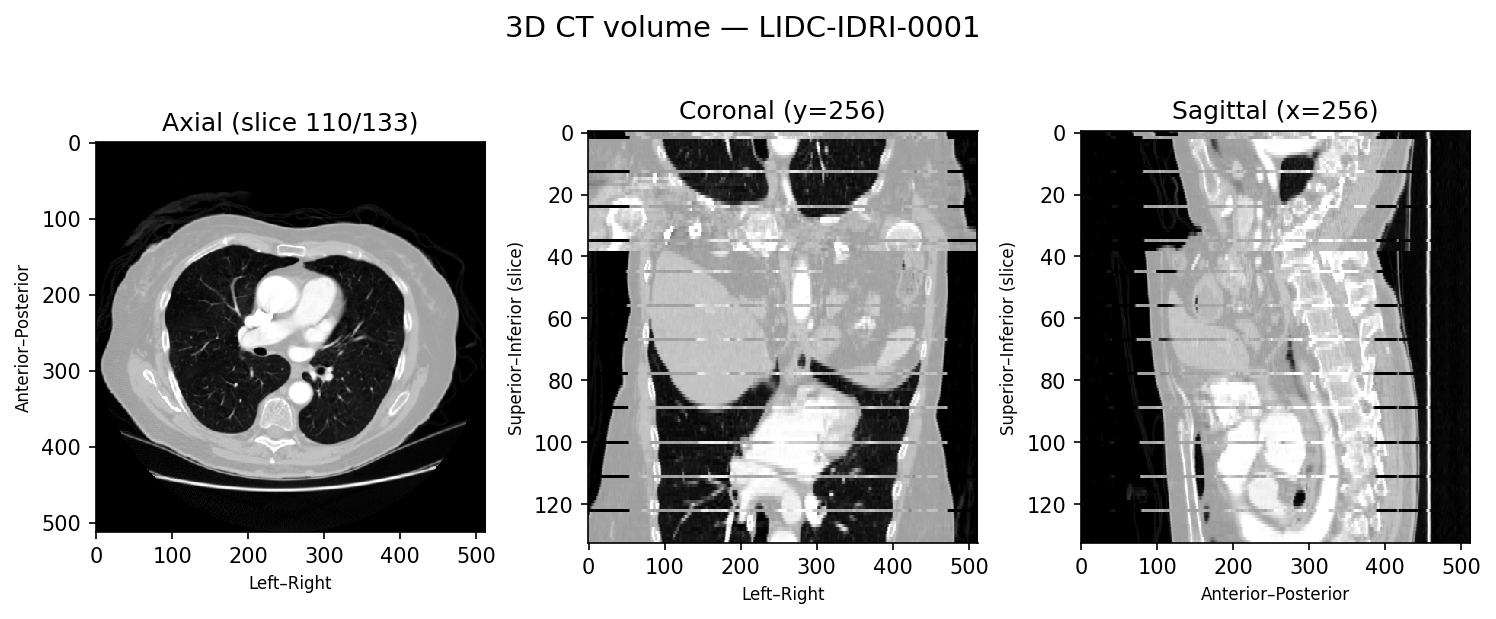

In [9]:
if npy_files:

    # load one patient's full volume and sort files by slice index
    first_patient = patients[0]
    patient_files = sorted(f for f in npy_files if f.parent.name == first_patient)
    volume = np.stack([np.load(f).astype(np.float32) for f in patient_files], axis=0)

    # print summary of volume properties
    print(f"Patient      : {first_patient}")
    print(f"Volume shape : {volume.shape}  (depth × height × width)")
    print(f"HU range     : [{volume.min():.0f}, {volume.max():.0f}]")

    D, H, W = volume.shape

    # plot three orthogonal views with lung windowing
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    axes[0].imshow(apply_lung_window(volume[5*D//6]), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Axial (slice {5*D//6}/{D})")
    axes[0].set_xlabel("Left–Right", fontsize=8)
    axes[0].set_ylabel("Anterior–Posterior", fontsize=8)

    axes[1].imshow(apply_lung_window(volume[:, H//2, :]), cmap="gray", vmin=0, vmax=1, aspect="auto")
    axes[1].set_title(f"Coronal (y={H//2})")
    axes[1].set_xlabel("Left–Right", fontsize=8)
    axes[1].set_ylabel("Superior–Inferior (slice)", fontsize=8)

    axes[2].imshow(apply_lung_window(volume[:, :, W//2]), cmap="gray", vmin=0, vmax=1, aspect="auto")
    axes[2].set_title(f"Sagittal (x={W//2})")
    axes[2].set_xlabel("Anterior–Posterior", fontsize=8)
    axes[2].set_ylabel("Superior–Inferior (slice)", fontsize=8)

    plt.suptitle(f"3D CT volume — {first_patient}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/05_3d_views.pdf", bbox_inches="tight")
    plt.show()

The axial view shows a standard chest CT cross-section with clearly visible lung fields, heart, and spine. The coronal and sagittal views reveal the full
superior-inferior extent of the scan from chest to abdomen. The horizontal banding visible in these views is a known artefact of the acquisition, as clinical CT scans are not always acquired at uniform slice spacing, and LION's preprocessing does not resample to a uniform z-resolution. This does not affect reconstruction quality since LION processes each axial slice independently.

## 9. Axial Slice Progression

To understand why a patient-level train/test split is necessary, it is useful to visualise how slices from the same patient vary across the volume. If slices were split at the individual level rather than the patient level, near-identical slices from the same patient could appear in both the training and test sets, causing the model to appear to generalise when it is simply memorising patient-specific anatomy.

The plot below samples 15 evenly-spaced slices from a single patient, showing the full extent of the scan from the upper chest down through the abdomen.

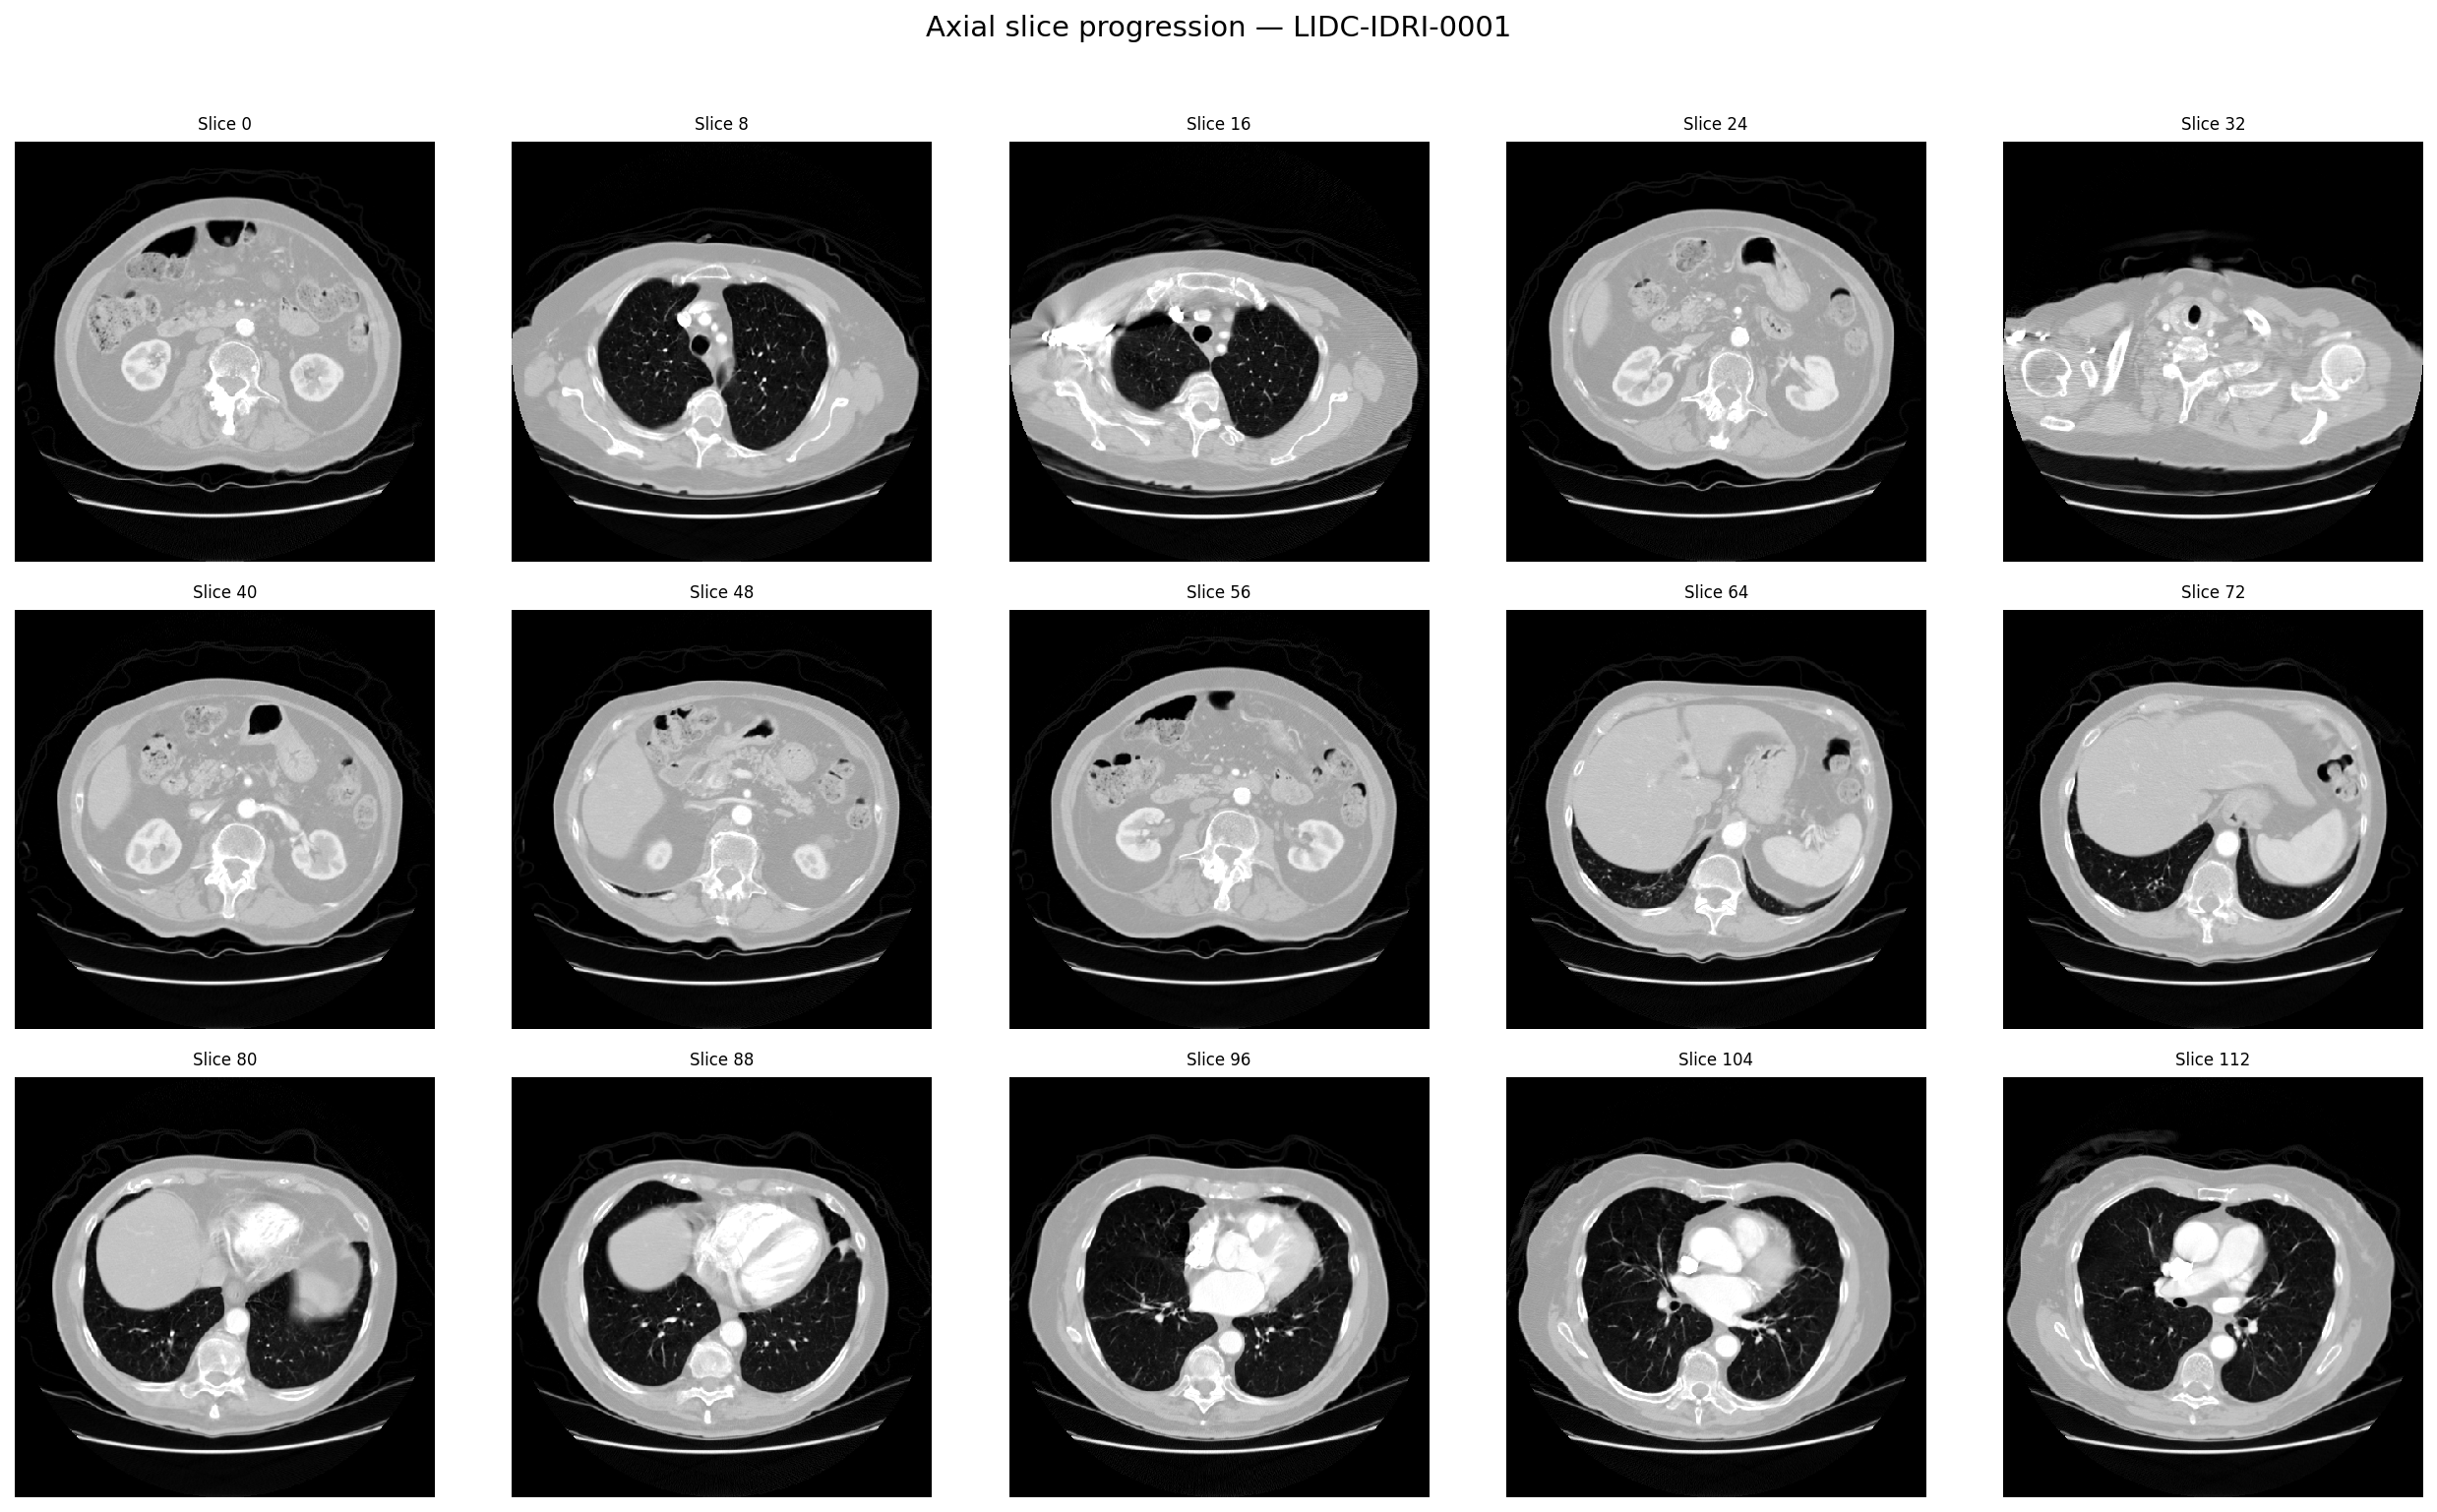

In [10]:
if npy_files:

    # sample 15 slices evenly spaced through the volume
    step = max(1, len(patient_files) // 15)
    sample_indices = list(range(0, len(patient_files), step))[:15]

    # plot gallery of sampled slices with lung windowing
    fig, axes = plt.subplots(3, 5, figsize=(17, 10))
    axes = axes.ravel()

    for ax, idx in zip(axes, sample_indices):
        img = np.load(patient_files[idx]).astype(np.float32)
        ax.imshow(apply_lung_window(img), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Slice {idx}", fontsize=8)
        ax.axis("off")

    # show and save figure
    plt.suptitle(f"Axial slice progression — {first_patient}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/06_slice_progression.pdf", bbox_inches="tight")
    plt.show()

The progression shows that adjacent slices are highly similar, differing only by a few millimetres of anatomy. This is why LION splits the dataset at the patient level rather than the slice level, because if slices from the same patient appeared in both training and test sets, the model could trivially generalise by memorising patient-specific anatomy rather than learning a general reconstruction strategy, artificially inflating evaluation metrics.

## 10. Intensity Distribution Analysis

Understanding the intensity distribution of the dataset is important for:

- Understanding which slices contain useful anatomical content and which are mostly air, as low-std slices provide little training signal
- Checking data quality to prevent unexpected distributions from flagging preprocessing errors
- Understanding the range of values the denoiser and CT operator will receive after `ct.from_HU_to_mu()` is applied at load time

This is illustrated by plotting three figures: 

- a pooled pixel histogram across 5 randomly sampled slices, which shows the characteristic bimodal HU distribution with a sharp air peak at −1000 and a broader soft tissue peak near 0.
- a scatter plot of mean HU per slice, which shows how slices with means close to −1000 correspond to mostly-air regions above or below the patient.
- a scatter plot of standard deviation per slice, which shows that informative slices containing organ boundaries and lung parenchyma have substantially higher std than featureless air-only slices.

Statistics over 103 sampled slices:
  Mean of means : -953.5 HU
  Mean of stds  : 958.1 HU
  Min observed  : -3024 HU
  Max observed  : 5590 HU


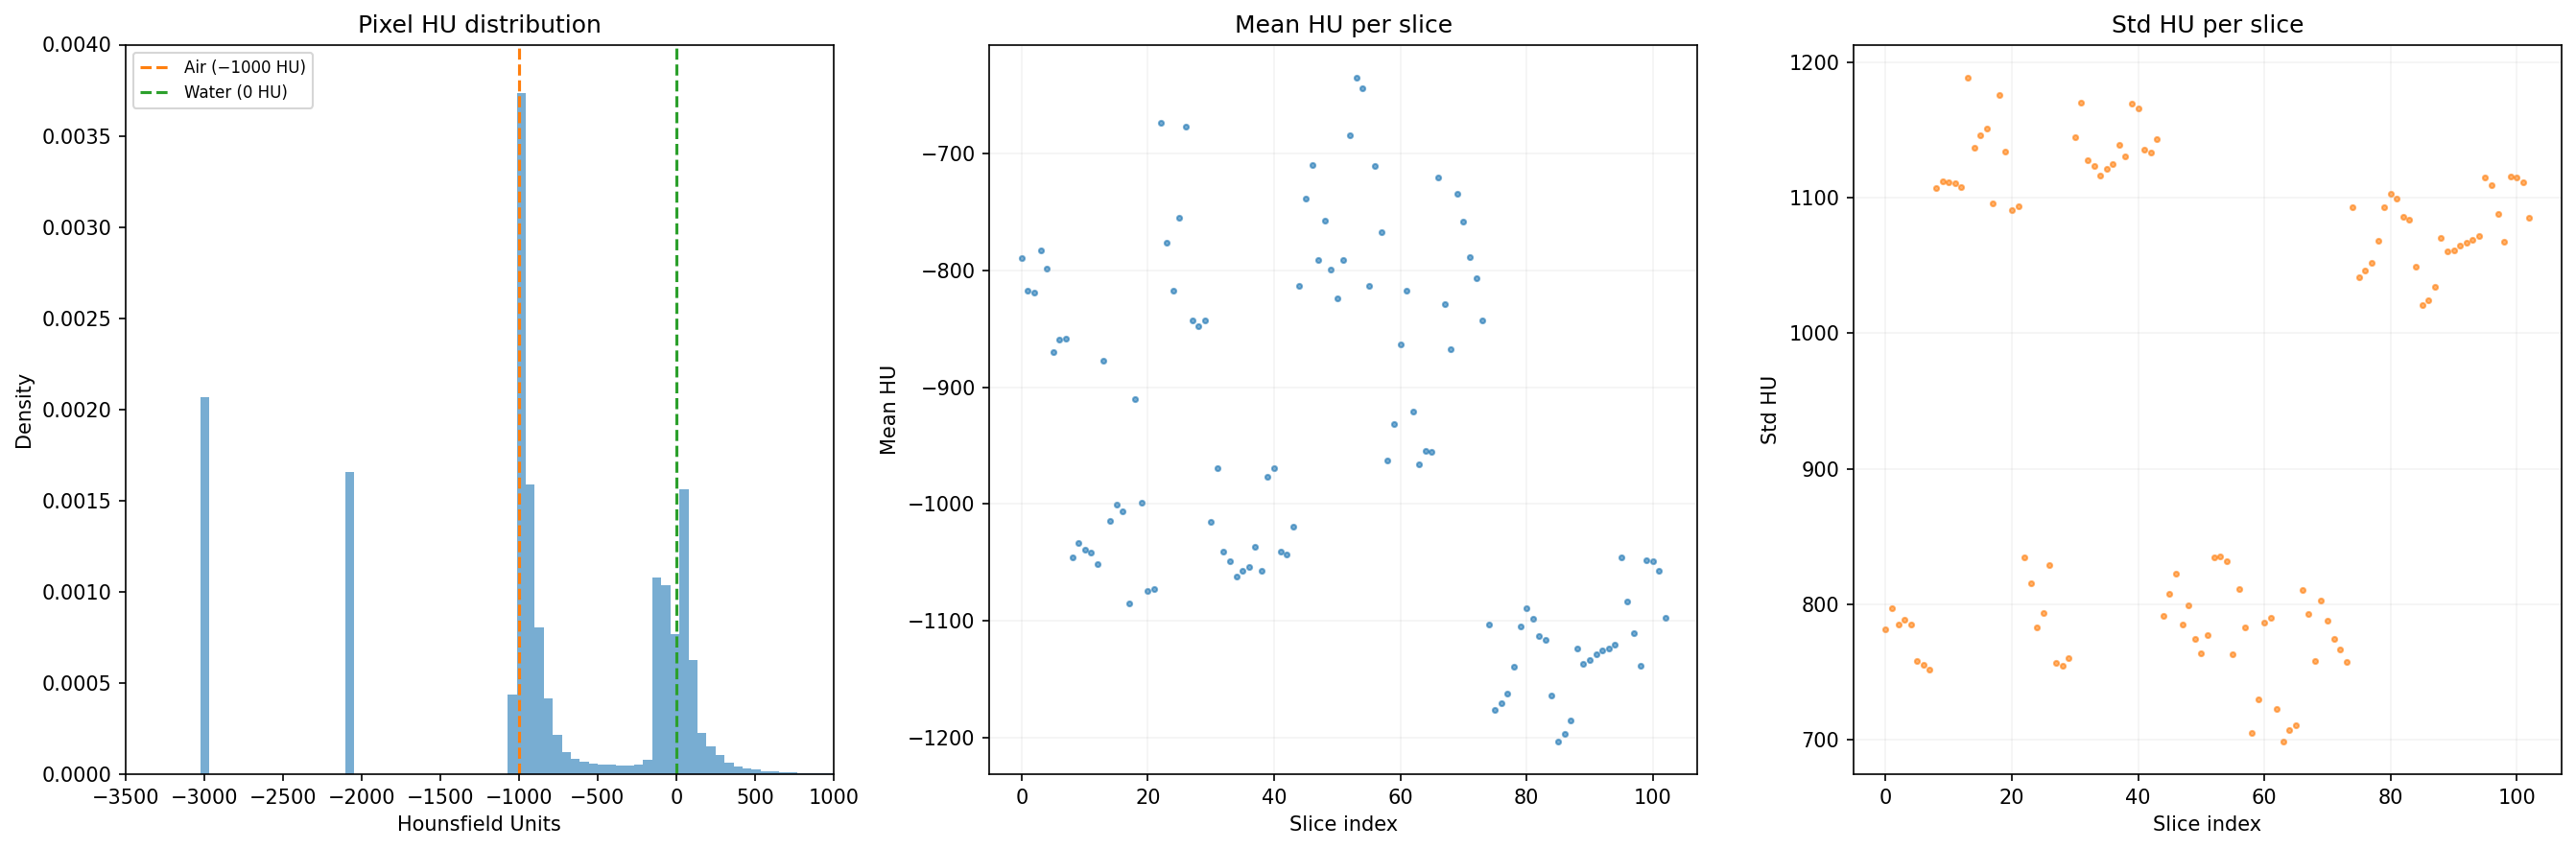

In [11]:
if npy_files:

    # Sample up to 100 slices for speed
    sample_files = npy_files[::max(1, len(npy_files)//100)]
    all_means, all_stds, all_mins, all_maxs = [], [], [], []

    # Loop through sampled files and compute statistics
    for f in sample_files:
        img = np.load(f).astype(np.float32)
        all_means.append(img.mean())
        all_stds.append(img.std())
        all_mins.append(img.min())
        all_maxs.append(img.max())

    print(f"Statistics over {len(sample_files)} sampled slices:")
    print(f"  Mean of means : {np.mean(all_means):.1f} HU")
    print(f"  Mean of stds  : {np.mean(all_stds):.1f} HU")
    print(f"  Min observed  : {min(all_mins):.0f} HU")
    print(f"  Max observed  : {max(all_maxs):.0f} HU")

    # plot histograms and scatter plots of statistics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    all_pixels = np.concatenate([np.load(f).astype(np.float32).ravel() for f in sample_files])

    axes[0].hist(all_pixels, bins=150, color="C0", alpha=0.6, edgecolor="none", density=True)
    axes[0].axvline(-1000, color="C1", ls="--", lw=1.5, label="Air (−1000 HU)")
    axes[0].axvline(    0, color="C2", ls="--", lw=1.5, label="Water (0 HU)")

    # clipped display range to eliminate empty space
    axes[0].set_xlim(-3500, 1000)
    axes[0].set_ylim(0, 0.004)

    axes[0].set_xlabel("Hounsfield Units")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Pixel HU distribution")
    axes[0].legend(fontsize=8)

    axes[1].scatter(range(len(all_means)), all_means, s=6, alpha=0.6, c="C0")
    axes[1].grid(True, alpha=0.15)
    axes[1].set_xlabel("Slice index")
    axes[1].set_ylabel("Mean HU")
    axes[1].set_title("Mean HU per slice")

    axes[2].scatter(range(len(all_stds)), all_stds, s=6, alpha=0.6, c="C1")
    axes[2].grid(True, alpha=0.15)
    axes[2].set_xlabel("Slice index")
    axes[2].set_ylabel("Std HU")
    axes[2].set_title("Std HU per slice")

    # show and save figure
    plt.tight_layout()
    plt.savefig("../figures/03/07_intensity_distribution.pdf", bbox_inches="tight")
    plt.show()

## 11. Train / Validation / Test Split

LION splits the dataset at the **patient level** (not slice level) to prevent data leakage and ensure that slices from the same patient never appear in both
training and test sets as they are too similar.

The standard LION split (full 1018-patient dataset):

- Training (80%):
- Validation (10%): used for hyperparameter tuning
- Test (10%): held out for final evaluation

For the 10 patient subset a different fraction was chosen due to the scarcity of data:

- Training: patients 1–6 (60%)
- Validation: patients 7-8 (20%)
- Test: patients 9–10 (20%)

In [12]:
if npy_files:

    # sort patients
    all_patients = sorted(set(f.parent.name for f in npy_files))
    n = len(all_patients)
    
    # 60/10/30 split for our small subset
    n_train = int(0.6 * n)
    n_val   = max(1, int(0.2 * n))
    n_test  = n - n_train - n_val
    
    # simulate the patient-level split by slicing the sorted patient list
    train_patients = all_patients[:n_train]
    val_patients   = all_patients[n_train:n_train + n_val]
    test_patients  = all_patients[n_train + n_val:]
    
    # function to count slices in a list of patients
    def count_slices(pat_list):
        return sum(1 for f in npy_files if f.parent.name in pat_list)

    # print summary of split
    print("Patient-level split (subset_10):")
    print(f"  Train : {len(train_patients)} patients, {count_slices(train_patients)} slices")
    print(f"  Val   : {len(val_patients)} patients,  {count_slices(val_patients)} slices")
    print(f"  Test  : {len(test_patients)} patients,  {count_slices(test_patients)} slices")
    print()
    print("Train patients:", train_patients)
    print("Val patients  :", val_patients)
    print("Test patients :", test_patients)

Patient-level split (subset_10):
  Train : 6 patients, 1041 slices
  Val   : 2 patients,  278 slices
  Test  : 2 patients,  533 slices

Train patients: ['LIDC-IDRI-0001', 'LIDC-IDRI-0002', 'LIDC-IDRI-0003', 'LIDC-IDRI-0004', 'LIDC-IDRI-0005', 'LIDC-IDRI-0006']
Val patients  : ['LIDC-IDRI-0007', 'LIDC-IDRI-0008']
Test patients : ['LIDC-IDRI-0009', 'LIDC-IDRI-0010']


## 12. What the Model Actually Sees During Training

During training, the model receives **(sinogram, ground_truth)** pairs.
The ground truth is the processed CT slice (what we've been visualising).
The sinogram is computed on-the-fly by LION's CT operator (forward projection).

Let's simulate this to see both sides of the pair — using the same
scipy/skimage Radon transform from notebook 02, since tomosipo
isn't available locally.

/home/eaz21/rds/hpc-work/miniconda3/envs/mphil_ct/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


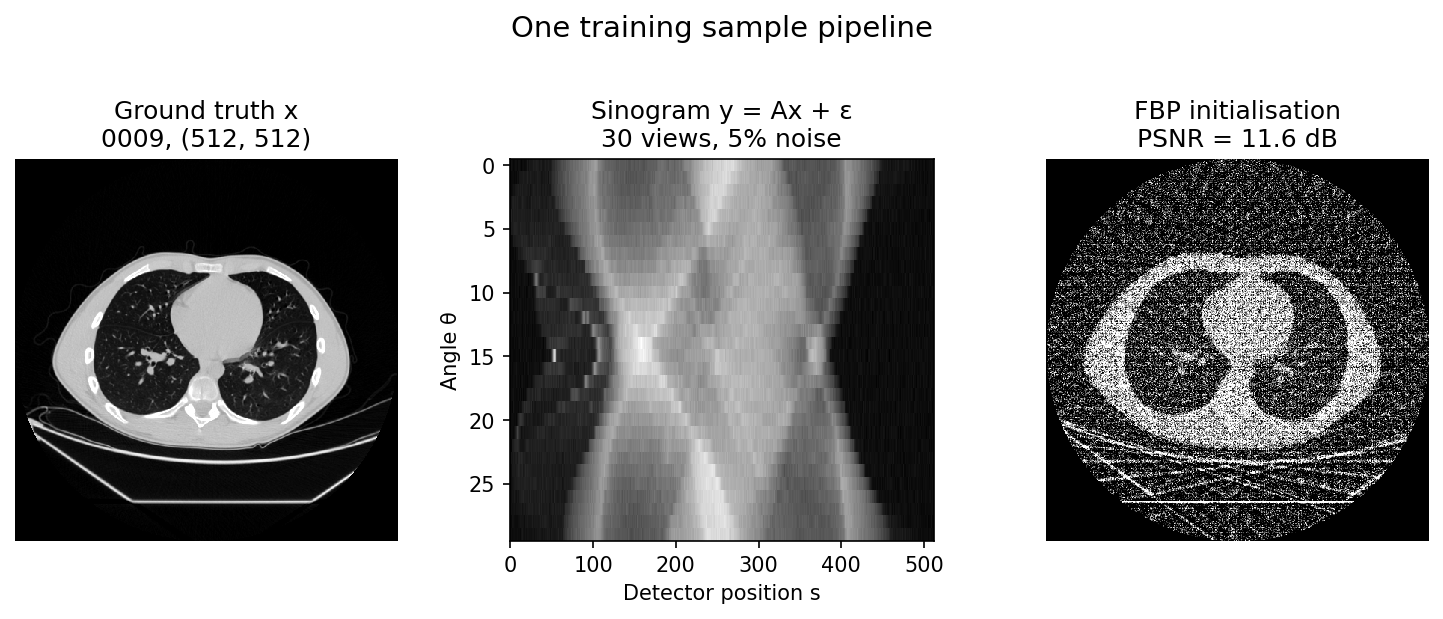

In [13]:
if npy_files:

    # find one slice likely to contain lung fields by checking for dark pixels in the centre
    def is_lung_slice(fpath, dark_threshold=-500, min_dark_fraction=0.15):
        """Returns True if the slice likely contains lung fields."""
        img = np.load(fpath).astype(np.float32)
        h, w = img.shape
        centre = img[h//4 : 3*h//4, w//5 : 4*w//5]
        return (centre < dark_threshold).mean() > min_dark_fraction

    # Pick an informative lung slice
    rng = np.random.default_rng(0)
    lung_slices = [f for f in npy_files if is_lung_slice(f)]
    candidates  = lung_slices if lung_slices else npy_files
    sample_file = rng.choice(candidates)

    # Load and apply lung window as proxy for ct.from_HU_to_mu
    raw_hu = np.load(sample_file).astype(np.float32)
    gt     = apply_lung_window(raw_hu) 

    # Simulate sinogram and FBP reconstruction for this slice
    N_VIEWS   = 30
    NOISE_STD = 0.05
    theta     = np.linspace(0, 180, N_VIEWS, endpoint=False)

    sinogram   = radon(gt, theta=theta, circle=True)
    sino_noisy = sinogram + np.random.default_rng(42).normal(
                     0, NOISE_STD * sinogram.std(), sinogram.shape)

    fbp_recon = np.clip(iradon(sino_noisy, theta=theta,
                               filter_name="ramp", circle=True), 0, 1)

    # define a function to compute PSNR between two images
    def psnr(a, b):
        mse = np.mean((a - b)**2)
        return 10 * np.log10(1.0 / mse) if mse > 0 else float("inf")

    # plot the ground truth, sinogram, and FBP reconstruction side by side
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    axes[0].imshow(gt, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Ground truth x\n" f"{sample_file.parent.name[-4:]}, {gt.shape}")
    axes[0].axis("off")

    axes[1].imshow(sino_noisy.T, cmap="gray", aspect="auto")
    axes[1].set_title(f"Sinogram y = Ax + ε\n30 views, 5% noise")
    axes[1].set_xlabel("Detector position s")
    axes[1].set_ylabel("Angle θ")

    axes[2].imshow(fbp_recon, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title(f"FBP initialisation\nPSNR = {psnr(gt, fbp_recon):.1f} dB")
    axes[2].axis("off")

    # show and save figure
    plt.suptitle("One training sample pipeline", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/08_training_sample.pdf", bbox_inches="tight")
    plt.show()

The figure above successfully shows the journey of one training sample through the CT acquisition and reconstruction pipeline. 

A real CT slice from the LIDC-IDRI dataset represents the ground truth image. The left hand side plot has a lung window applied to it for clarity, but there are no other modifications. This represents what the model is trying to reconstruct, and is the target that the loss function compares against during training.

The middle plot is the sinogram illustrating the result of forward projecting the ground truth through only 30 angles, as well as adding 5% Gaussian noise. Each row of the sinogram corresponds to a projection angle, with in the sparse case shown, can be clearly distinguished between. This sinogram is the degraded measurement that the model receives as an input. We can see now why reconstruction is difficult, as compared to the previoiusly seen sinograms generated on the full 720-projection range, the quality of the sparse view sinogram is extremely bad. 

The right plot is the FBP initialisation, showing the result of applying filtered backprojection to the noisy sinogram. The PSNR is severely degraded at 11.6 dB, with circular streak srtefacts visible, as well as significant static noise throughout the image. This is the starting point that the ADMM sovler is initialised to in our model, before the policy network begins iterating. 

## 13. Summary

This notebook explored the structure and characteristics of the LIDC-IDRI CT dataset after conversion to Hounsfield Units (HU). Representative slices from multiple patients were visualised to assess anatomical variability, while intensity statistics and histograms were used to examine the distribution of HU values across the dataset. Clinical windowing was applied to demonstrate how different tissue types can be emphasised for diagnostic interpretation. Overall, the dataset was found to contain consistent CT intensity ranges and substantial variation in anatomy and scan position, providing a realistic testbed for subsequent reconstruction and image analysis experiments.